<a href="https://colab.research.google.com/github/opinner/thesis_introductory_figures/blob/main/gm_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import gm

import matplotlib.pyplot as plt

In [10]:

class GmModel():
    """
    Is inheritance from spectrum useful?

    # GM equations are copied from https://github.com/joernc/GM81
    # under the GNU General Public License.
    # This module implements the empirical spectrum of internal waves developed by
    # Garrett and Munk, in the incarnation presented in Munk's chapter in Evolution
    # of Physical Oceanography, which can be downloaded here:
    # http://ocw.mit.edu/resources/res-12-000-evolution-of-physical-oceanography-spring-2007/part-2/wunsch_chapter9.pdf
    # The variable names follow Munk's notation.
    """

    """
    #Class Attributes
    E = 6.3e-5 # Energy parameter
    JS = 3 # j_* (j star)
    JSUM = (np.pi*js/np.tanh(np.pi*js)-1)/(2*js**2) #sum_1^infty (j^2+j_*^2)^-1
    g = 9.81 # gravitational acceleration
    """


    def __init__(self):
        self.f = None # Coriolis frequency in rad/s
        self.N0 = None  # surface-extrapolated buoyancy frequency
        self.b = None # e-folding scale of N(z)
        self.N = None # buoyancy frequency (corresponding to 1000 m depth)
        self.frequencies = None #frequencies
        self.freq_unit = None
        self.ke_psd = None #Kinetic energy spectrum
        self.pe_psd = None #Potential energy spectrum
        self.psd_unit = None


    def set_parameters(self, f = 7.3e-5, N0 = 5.2e-3, b = 1300):
        """
        Calculate the GM81 Kinetic Energy spectrum from the given parameters
        The default parameters are the original example values in the GM81 publication
        This method does not return anything
        """

        self.f = f #corfreq(lat) / (3600*24) # Coriolis frequency in rad/s
        self.N0 = N0  # surface-extrapolated buoyancy frequency
        self.b = b # e-folding scale of N(z)
        self.N = N0 * np.exp(1000/b) #2.4e-3  # buoyancy frequency (corresponding to 1000 m

        omg, K_omg, P_omg = self.calculate_spectra(N0=self.N0,b=self.b,N=self.N)

        self.frequencies = 3600*24*omg/(2*np.pi)
        self.freq_units = "cpd"
        self.ke_psd = 2*np.pi*K_omg/3600/24
        self.pe_psd = 2*np.pi*P_omg/3600/24
        self.psd_unit = "m^2/(s^2 d)"

        return

    def get_parameters(self):
        return self.f,self.N0,self.b,self.N

    def fit_parameters(self, spectrum, f= 7.3e-5, N0 = 5.2e-3, b = 1300, N = None):
        """
        Fit a GM81 Kinetic Energy spectrum onto a given spectrum
        N0 and b are the model parameters, which can be tweaked
        The method returns the end result of the model parameters N0, b and N
        """
        raise NotImplementedError
        """
        self.f = f #help.corfreq(lat) / (3600*24) # Coriolis frequency in rad/s
        if N is None: #if N is not given explicitly, do not use it as a fitting parameter
            N = N0 * np.exp(1000/b)


        #compare units
        if spectrum.freq_units != "cpd": raise ValueError
        if spectrum.psd_units != "m^2/s^2/cpd": raise ValueError

        #fitting block
        #still no clue on how to do it
        spectrum.frequencies
        spectrum.psd
        omg, K_omg, P_omg = calculate_spectra(self.f,N0,b,N)

        #set object attributes
        self.frequencies = 3600*24*omg/(2*np.pi)
        self.freq_units = "cpd"
        self.ke_psd = 2*np.pi*K_omg/3600/24
        self.psd_unit = "m^2/s^2/cpd"
        self.N0 = N0
        self.b = b
        self.N = N

        return N0,b,N
        """


    def calculate_spectra(self,N0,b,N):
        """
        Here happens the actual calculation of the GM81 spectrum.
        GM equations are copied from https://github.com/joernc/GM81
        under the GNU General Public License.
        """
        # This module implements the empirical spectrum of internal waves developed by
        # Garrett and Munk, in the incarnation presented in Munk's chapter in Evolution
        # of Physical Oceanography, which can be downloaded here:
        # http://ocw.mit.edu/resources/res-12-000-evolution-of-physical-oceanography-spring-2007/part-2/wunsch_chapter9.pdf
        # The variable names follow Munk's notation.

        # frequency
        omg = np.logspace(np.log10(1.01*self.f), np.log10(self.N), 401) #Where does the 401 come from?

        # horizontal wavenumber
        k = 2*np.pi*np.logspace(-6, -2, 401)

        # mode number
        j = np.arange(1, 100)

        # reshape to allow multiplication into 2D array
        Omg = np.reshape(omg, (omg.size,1))
        K = np.reshape(k, (k.size,1))
        J = np.reshape(j, (1,j.size))

        # frequency spectra (KE and PE)
        K_omg_j = gm.K_omg_j(Omg, J, self.f, self.N, self.N0, self.b)
        P_omg_j = gm.P_omg_j(Omg, J, self.f, self.N, self.N0, self.b)

        # wavenumber spectra (KE and PE)
        K_k_j = gm.K_k_j(K, J, self.f, self.N, self.N0, self.b)
        P_k_j = gm.P_k_j(K, J, self.f, self.N, self.N0, self.b)

        # sum over modes (j refers to modes)
        K_omg = np.sum(K_omg_j, axis=1)
        P_omg = np.sum(P_omg_j, axis=1)
        K_k = np.sum(K_k_j, axis=1)
        P_k = np.sum(P_k_j, axis=1)

        return omg, K_omg, P_omg


    # === Instance methods ===

    def to_radial_cps(self):
        if self.freq_units == "cps" and self.psd_unit == "m^2/s^2/cps":
            print("Units are already set to cps and m^2/s^2/cps")
            return

        if self.freq_units == "cpd" and self.psd_unit == "m^2/s^2/cpd":
            #Conversion to new units
            # TODO Why factor 2pi?
            self.frequencies = 1/(3600*24)*self.frequencies*(2*np.pi)
            self.ke_psd = 1/(2*np.pi)*self.ke_psd*3600*24
            self.pe_psd = 1/(2*np.pi)*self.pe_psd*3600*24
            #change unit name
            self.freq_units == "cps"
            self.psd_unit = "m^2/s^2/cps"
            return

        print("Units not recognized")
        return

    def to_cpd(self):
        if self.freq_units == "cpd" and self.psd_unit == "m^2/s^2/cpd":
            print("Units are already set to cpd and m^2/s^2/cpd")
            return

        if self.freq_units == "cps" and self.psd_unit == "m^2/s^2/cps":
            #Conversion to new units
            self.frequencies = 3600*24*self.frequencies/(2*np.pi)
            self.ke_psd = 2*np.pi*self.ke_psd/3600/24
            self.pe_psd = 2*np.pi*self.pe_psd/3600/24
            #change unit names
            self.freq_units == "cpd"
            self.psd_unit = "m^2/s^2/cpd)"
            return

        print("Units not recognized")
        return

    def plot_N_of_z(self,ax, z_range = (-5000,0), **Kwargs):
        def func(z, N0, b):
            return N0*np.exp(z/b)
        z = np.arange(-5000,0,10)
        ax.plot(func(z, self.N0, self.b),z,**Kwargs)
        return

    def plot(self,ax):#, **Kwargs):
        ax.loglog(self.frequencies, self.ke_psd, label='KE GM81')
        ax.loglog(self.frequencies, self.pe_psd, label='PE GM81')
        ax.axvline(self.f/2/np.pi, ls = "--", color = "k")
        ax.axvline(self.N0*24*3600, ls = ":", color = "r")

    def label_with_units(self,ax):
        ax.set_xlabel('Frequency {self.freq_unit}')
        if self.freq_unit == "m^2/s^2/cpd":
            freq_label = "(m$^2$/s$^2$/cpd)"
        else:
            freq_label = self.freq_unit
        ax.set_ylabel('PSD '+freq_label)





In [11]:
model = GmModel()
model.set_parameters()

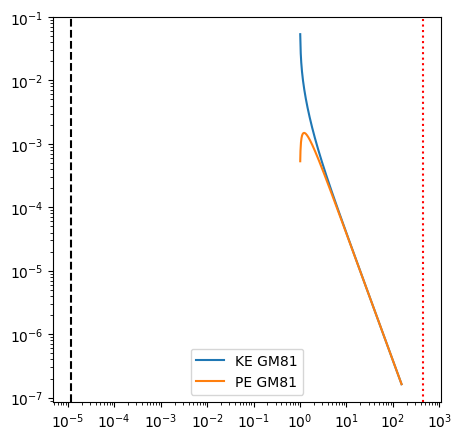

In [15]:
fig, ax = plt.subplots(1, figsize=(5,5))

model.plot(ax)
ax.legend()